In [3]:
import os
import pickle
import numpy as np
import pandas as pd
import scipy.signal
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

In [4]:
BINARY_LABELS = {1: 0, 3: 0, 2: 1}  # Baseline & Amusement = 0, Stress = 1
VALID_LABELS = [1, 2, 3]
TARGET_FS = 4
WINDOW_SEC = 30
STEP_SEC = 10

In [5]:
def inspect_subject_labels(subject_path):
    """Inspect labels in the data"""
    with open(subject_path, 'rb') as file:
        data = pickle.load(file, encoding='latin1')
    
    labels = data['label']
    unique_labels = np.unique(labels)
    label_counts = {}
    
    for label in unique_labels:
        count = np.sum(labels == label)
        duration = count / 700 / 60
        label_counts[label] = (count, duration)
    
    return label_counts

In [6]:
def load_wesad_data(subject_path):
    """Load WESAD pickle file"""
    with open(subject_path, 'rb') as file:
        data = pickle.load(file, encoding='latin1')
    return data


In [7]:

def align_wrist_signals(wrist_data, labels, target_fs=4):
    """
    Align wrist signals to unified 4 Hz sampling rate
    - ACC: 32 Hz → 4 Hz
    - BVP: 64 Hz → 4 Hz
    - EDA: 4 Hz (unchanged)
    - TEMP: 4 Hz (unchanged)
    """
    duration_sec = len(labels) / 700
    target_len = int(duration_sec * target_fs)
    
    acc = wrist_data['ACC']
    bvp = wrist_data['BVP']
    eda = wrist_data['EDA']
    temp = wrist_data['TEMP']
    
    # Resample all to target frequency
    acc_resampled = scipy.signal.resample(acc, target_len, axis=0) if acc.ndim == 2 else scipy.signal.resample(acc, target_len).reshape(-1, 1)
    bvp_resampled = scipy.signal.resample(bvp, target_len)
    eda_resampled = scipy.signal.resample(eda, target_len)
    temp_resampled = scipy.signal.resample(temp, target_len)
    labels_resampled = scipy.signal.resample(labels, target_len)
    labels_resampled = np.round(labels_resampled).astype(int)
    
    # Combine: ACC (3) + BVP (1) + EDA (1) + TEMP (1) = 6 features
    combined_data = np.hstack([
        acc_resampled,
        bvp_resampled.reshape(-1, 1),
        eda_resampled.reshape(-1, 1),
        temp_resampled.reshape(-1, 1)
    ])
    
    return combined_data, labels_resampled


In [8]:
def create_windows(data, labels, window_size, step_size, valid_labels):
    """Create sliding windows from data"""
    X = []
    y = []
    
    if len(data) < window_size:
        return np.array([]), np.array([])
    
    num_steps = (len(data) - window_size) // step_size + 1
    
    for i in range(num_steps):
        start = i * step_size
        end = start + window_size
        
        if end > len(data):
            break
        
        window_data = data[start:end]
        window_label = labels[end - 1]
        
        if window_label in valid_labels:
            X.append(window_data)
            y.append(BINARY_LABELS[window_label])
    
    return np.array(X), np.array(y)


In [9]:
def preprocess_subject(subject_path, target_fs=TARGET_FS, window_sec=WINDOW_SEC, step_sec=STEP_SEC):
    """Process single subject"""
    try:
        raw_data = load_wesad_data(subject_path)
        wrist_data = raw_data['signal']['wrist']
        labels = raw_data['label']
        
        aligned_data, aligned_labels = align_wrist_signals(wrist_data, labels, target_fs)
        
        scaler = StandardScaler()
        normalized_data = scaler.fit_transform(aligned_data)
        
        window_pts = int(window_sec * target_fs)
        step_pts = int(step_sec * target_fs)
        
        X, y = create_windows(normalized_data, aligned_labels, window_pts, step_pts, VALID_LABELS)
        
        return X, y
    except Exception as e:
        print(f"  Error: {e}")
        return np.array([]), np.array([])


In [10]:
base_path = '/kaggle/input/wesad-wearable-stress-affect-detection-dataset/WESAD'
subjects = ['S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9', 'S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17']

In [11]:
for subj in subjects:
    subj_path = os.path.join(base_path, subj, f'{subj}.pkl')
    if os.path.exists(subj_path):
        label_info = inspect_subject_labels(subj_path)
        print(f"\n{subj}:")
        for label, (count, duration) in sorted(label_info.items()):
            label_name = {1: "Baseline", 2: "Stress", 3: "Amusement", 0: "Transient"}.get(label, "Unknown")
            print(f"  Label {label} ({label_name:12}): {count:6,} samples = {duration:5.1f} min")



S2:
  Label 0 (Transient   ): 2,142,701 samples =  51.0 min
  Label 1 (Baseline    ): 800,800 samples =  19.1 min
  Label 2 (Stress      ): 430,500 samples =  10.2 min
  Label 3 (Amusement   ): 253,400 samples =   6.0 min
  Label 4 (Unknown     ): 537,599 samples =  12.8 min
  Label 6 (Unknown     ): 45,500 samples =   1.1 min
  Label 7 (Unknown     ): 44,800 samples =   1.1 min

S3:
  Label 0 (Transient   ): 2,345,699 samples =  55.8 min
  Label 1 (Baseline    ): 798,000 samples =  19.0 min
  Label 2 (Stress      ): 448,000 samples =  10.7 min
  Label 3 (Amusement   ): 262,500 samples =   6.2 min
  Label 4 (Unknown     ): 546,001 samples =  13.0 min
  Label 5 (Unknown     ): 51,100 samples =   1.2 min
  Label 6 (Unknown     ): 46,900 samples =   1.1 min
  Label 7 (Unknown     ): 46,900 samples =   1.1 min

S4:
  Label 0 (Transient   ): 2,314,199 samples =  55.1 min
  Label 1 (Baseline    ): 810,601 samples =  19.3 min
  Label 2 (Stress      ): 444,500 samples =  10.6 min
  Label 3 (A

In [12]:
all_X = []
all_y = []
subject_indices = []

for subj in subjects:
    subj_path = os.path.join(base_path, subj, f'{subj}.pkl')
    if os.path.exists(subj_path):
        X_sub, y_sub = preprocess_subject(subj_path)
        
        if len(X_sub) > 0:
            all_X.append(X_sub)
            all_y.append(y_sub)
            subject_indices.extend([subj] * len(X_sub))
            
            stress_count = np.sum(y_sub)
            non_stress_count = len(y_sub) - stress_count
            print(f"✓ {subj}: {len(X_sub):3d} windows | Stress: {stress_count:2d} | Non-stress: {non_stress_count:2d}")


✓ S2: 212 windows | Stress: 61 | Non-stress: 151
✓ S3: 215 windows | Stress: 64 | Non-stress: 151
✓ S4: 216 windows | Stress: 63 | Non-stress: 153
✓ S5: 221 windows | Stress: 64 | Non-stress: 157
✓ S6: 221 windows | Stress: 65 | Non-stress: 156
✓ S7: 220 windows | Stress: 64 | Non-stress: 156
✓ S8: 221 windows | Stress: 67 | Non-stress: 154
✓ S9: 220 windows | Stress: 64 | Non-stress: 156
✓ S10: 227 windows | Stress: 72 | Non-stress: 155
✓ S11: 223 windows | Stress: 68 | Non-stress: 155
✓ S13: 222 windows | Stress: 66 | Non-stress: 156
✓ S14: 222 windows | Stress: 67 | Non-stress: 155
✓ S15: 223 windows | Stress: 69 | Non-stress: 154
✓ S16: 222 windows | Stress: 68 | Non-stress: 154
✓ S17: 227 windows | Stress: 72 | Non-stress: 155


In [13]:
if len(all_X) == 0:
    print("ERROR: No data loaded!")
    exit()

X_final = np.concatenate(all_X, axis=0)
y_final = np.concatenate(all_y, axis=0)


In [14]:
print(f"TOTAL SAMPLES: {len(X_final)}")
print(f"Feature shape: {X_final.shape}")
print(f"\nClass distribution:")
print(f"  Stress (1): {np.sum(y_final):5d} ({np.sum(y_final)/len(y_final)*100:.1f}%)")
print(f"  Non-stress (0): {len(y_final) - np.sum(y_final):5d} ({(1 - np.sum(y_final)/len(y_final))*100:.1f}%)")
print(f"  Imbalance ratio: {np.sum(y_final) / (len(y_final) - np.sum(y_final)):.3f}")

TOTAL SAMPLES: 3312
Feature shape: (3312, 120, 6)

Class distribution:
  Stress (1):   994 (30.0%)
  Non-stress (0):  2318 (70.0%)
  Imbalance ratio: 0.429


In [15]:
unique_subjects = sorted(list(set(subject_indices)))
np.random.seed(42)
test_subjects = np.random.choice(unique_subjects, size=max(1, len(unique_subjects)//3), replace=False)


In [16]:
train_mask = np.array([s not in test_subjects for s in subject_indices])
test_mask = ~train_mask

In [17]:
X_train, X_test = X_final[train_mask], X_final[test_mask]
y_train, y_test = y_final[train_mask], y_final[test_mask]

In [18]:
print(f"Train set: {len(X_train):5d} samples | Stress: {np.sum(y_train):3d} | Non-stress: {len(y_train) - np.sum(y_train):3d}")
print(f"Test set:  {len(X_test):5d} samples | Stress: {np.sum(y_test):3d} | Non-stress: {len(y_test) - np.sum(y_test):3d}")
print(f"Train subjects: {sorted([s for s in unique_subjects if s not in test_subjects])}")
print(f"Test subjects: {sorted(test_subjects)}\n")

Train set:  2205 samples | Stress: 659 | Non-stress: 1546
Test set:   1107 samples | Stress: 335 | Non-stress: 772
Train subjects: ['S11', 'S13', 'S14', 'S15', 'S17', 'S2', 'S3', 'S5', 'S7', 'S9']
Test subjects: [np.str_('S10'), np.str_('S16'), np.str_('S4'), np.str_('S6'), np.str_('S8')]



In [19]:
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}

In [20]:
print(f"Class weights:")
print(f"  Non-stress: {class_weight_dict[0]:.3f}")
print(f"  Stress: {class_weight_dict[1]:.3f}\n")

Class weights:
  Non-stress: 0.713
  Stress: 1.673



In [21]:
input_shape = (X_train.shape[1], X_train.shape[2])
print(f"Model input shape: {input_shape}\n")

Model input shape: (120, 6)



In [22]:
model = Sequential([
    GRU(64, return_sequences=True, input_shape=input_shape),
    Dropout(0.3),
    GRU(32, return_sequences=False),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

2026-01-03 12:37:34.102180: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [23]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

In [24]:
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 120, 64)        │        13,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 120, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,777 (92.88 KB)

 Trainable params: 23,777 (92.88 KB)

 Non-trainable params: 0 (0.00 B)

None


In [25]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)


In [26]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=30,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 15s 143ms/step - accuracy: 0.7158 - auc: 0.8038 - loss: 0.5457 - val_accuracy: 0.8907 - val_auc: 0.9842 - val_loss: 0.2349
Epoch 2/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 9s 136ms/step - accuracy: 0.8982 - auc: 0.9398 - loss: 0.3073 - val_accuracy: 0.9521 - val_auc: 0.9917 - val_loss: 0.1335
Epoch 3/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 9s 134ms/step - accuracy: 0.9248 - auc: 0.9645 - loss: 0.2398 - val_accuracy: 0.9666 - val_auc: 0.9945 - val_loss: 0.1238
Epoch 4/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 10s 138ms/step - accuracy: 0.9300 - auc: 0.9692 - loss: 0.2135 - val_accuracy: 0.9612 - val_auc: 0.9956 - val_loss: 0.1136
Epoch 5/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 9s 135ms/step - accuracy: 0.9426 - auc: 0.9789 - loss: 0.1815 - val_accuracy: 0.9639 - val_auc: 0.9937 - val_loss: 0.1314
Epoch 6/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 9s 136ms/step - accuracy: 0.9473 - auc: 0.9778 - loss: 0.1743 - val_accuracy: 0.9539 - val_auc: 0.9924 - val_loss: 0.1489
Epoch 7/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 

In [27]:
history_df = pd.DataFrame(history.history)
print(history_df.tail(10).to_string())

history_df.to_csv('training_history.csv', index_label='Epoch')

    accuracy       auc      loss  val_accuracy   val_auc  val_loss
2   0.931519  0.965803  0.227048      0.966576  0.994511  0.123779
3   0.931519  0.967987  0.215267      0.961156  0.995629  0.113627
4   0.943311  0.975021  0.188012      0.963866  0.993688  0.131398
5   0.944218  0.975486  0.183603      0.953930  0.992356  0.148902
6   0.952381  0.979796  0.171277      0.969286  0.993628  0.100461
7   0.955556  0.982599  0.160141      0.953026  0.990409  0.133068
8   0.955556  0.986365  0.139828      0.964770  0.991130  0.115790
9   0.964172  0.987786  0.126230      0.949413  0.985276  0.151700
10  0.963265  0.986492  0.132140      0.959350  0.986641  0.133671
11  0.963719  0.990485  0.116605      0.956640  0.982588  0.156558


# Plot training history

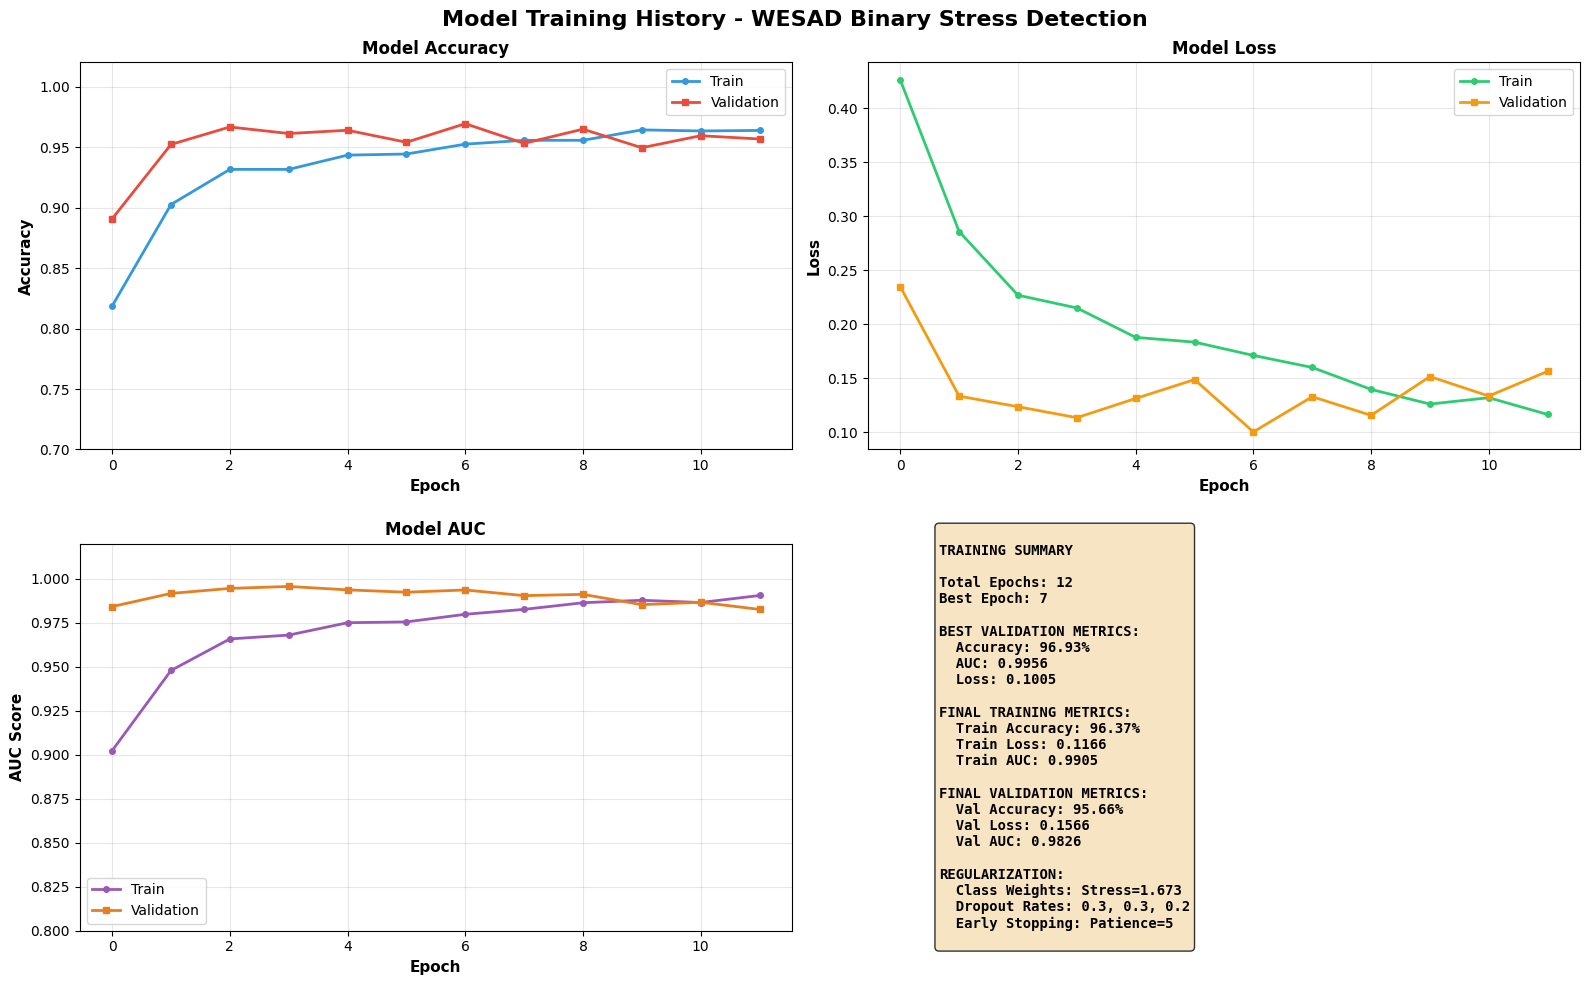

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Model Training History - WESAD Binary Stress Detection', fontsize=16, fontweight='bold')

axes[0, 0].plot(history.history['accuracy'], 'o-', linewidth=2, markersize=4, label='Train', color='#3498db')
axes[0, 0].plot(history.history['val_accuracy'], 's-', linewidth=2, markersize=4, label='Validation', color='#e74c3c')
axes[0, 0].set_xlabel('Epoch', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Accuracy', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Model Accuracy', fontsize=12, fontweight='bold')
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_ylim([0.7, 1.02])

axes[0, 1].plot(history.history['loss'], 'o-', linewidth=2, markersize=4, label='Train', color='#2ecc71')
axes[0, 1].plot(history.history['val_loss'], 's-', linewidth=2, markersize=4, label='Validation', color='#f39c12')
axes[0, 1].set_xlabel('Epoch', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Loss', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Model Loss', fontsize=12, fontweight='bold')
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(history.history['auc'], 'o-', linewidth=2, markersize=4, label='Train', color='#9b59b6')
axes[1, 0].plot(history.history['val_auc'], 's-', linewidth=2, markersize=4, label='Validation', color='#e67e22')
axes[1, 0].set_xlabel('Epoch', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('AUC Score', fontsize=11, fontweight='bold')
axes[1, 0].set_title('Model AUC', fontsize=12, fontweight='bold')
axes[1, 0].legend(fontsize=10)
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_ylim([0.8, 1.02])

best_epoch = np.argmin(history.history['val_loss']) + 1
best_val_acc = np.max(history.history['val_accuracy'])
best_val_auc = np.max(history.history['val_auc'])
best_val_loss = np.min(history.history['val_loss'])

summary_text = f"""
TRAINING SUMMARY

Total Epochs: {len(history.history['loss'])}
Best Epoch: {best_epoch}

BEST VALIDATION METRICS:
  Accuracy: {best_val_acc*100:.2f}%
  AUC: {best_val_auc:.4f}
  Loss: {best_val_loss:.4f}

FINAL TRAINING METRICS:
  Train Accuracy: {history.history['accuracy'][-1]*100:.2f}%
  Train Loss: {history.history['loss'][-1]:.4f}
  Train AUC: {history.history['auc'][-1]:.4f}

FINAL VALIDATION METRICS:
  Val Accuracy: {history.history['val_accuracy'][-1]*100:.2f}%
  Val Loss: {history.history['val_loss'][-1]:.4f}
  Val AUC: {history.history['val_auc'][-1]:.4f}

REGULARIZATION:
  Class Weights: Stress={class_weight_dict[1]:.3f}
  Dropout Rates: 0.3, 0.3, 0.2
  Early Stopping: Patience=5
"""

axes[1, 1].text(0.1, 0.5, summary_text, transform=axes[1, 1].transAxes, fontsize=10, verticalalignment='center',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8), family='monospace', fontweight='bold')
axes[1, 1].axis('off')

plt.tight_layout()
plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
plt.show()

In [29]:
loss, accuracy, auc = model.evaluate(X_test, y_test, verbose=0)
print(f"\n{'='*60}")
print(f"Test Accuracy: {accuracy*100:.2f}%")
print(f"Test AUC: {auc:.4f}")


Test Accuracy: 96.93%
Test AUC: 0.9936


In [30]:
y_pred_probs = model.predict(X_test, verbose=0)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

# Confusion Matrix

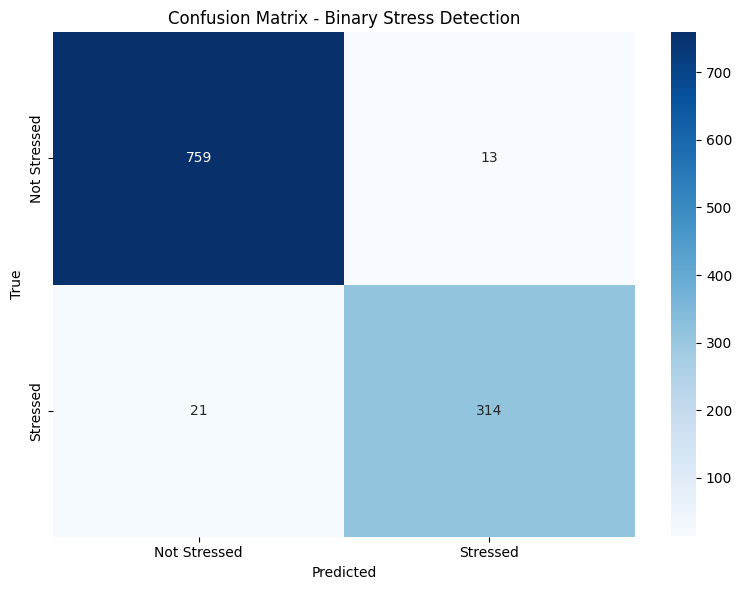

In [31]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Stressed', 'Stressed'], yticklabels=['Not Stressed', 'Stressed'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Binary Stress Detection')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Classification Report

In [32]:
print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=['Not Stressed', 'Stressed']))

Classification Report:

              precision    recall  f1-score   support

Not Stressed       0.97      0.98      0.98       772
    Stressed       0.96      0.94      0.95       335

    accuracy                           0.97      1107
   macro avg       0.97      0.96      0.96      1107
weighted avg       0.97      0.97      0.97      1107



# ROC Curve

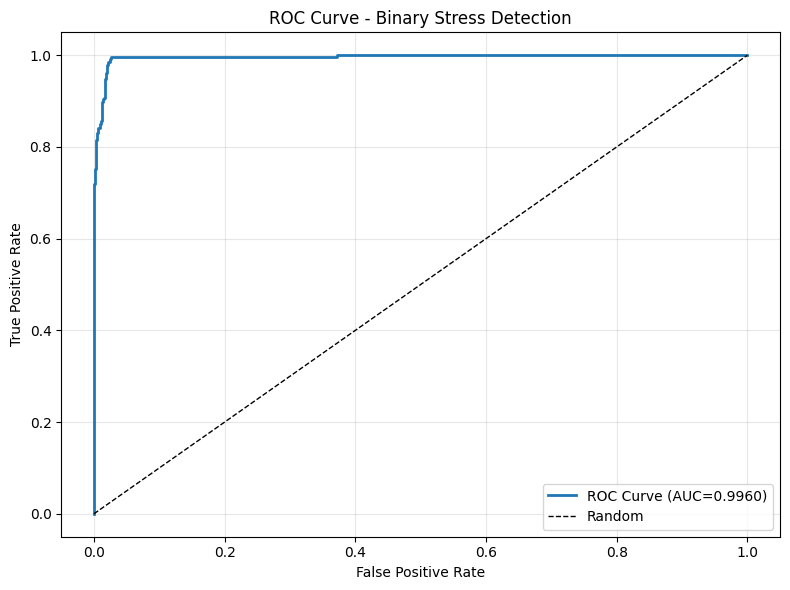

In [33]:
fpr, tpr, _ = roc_curve(y_test, y_pred_probs)
auc_score = roc_auc_score(y_test, y_pred_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC={auc_score:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Binary Stress Detection')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

# Save

In [34]:
model.save('wesad_stress_detector_model.h5')

In [35]:
scaler_for_inference = StandardScaler()
scaler_for_inference.fit(X_train.reshape(X_train.shape[0] * X_train.shape[1], X_train.shape[2]))
joblib.dump(scaler_for_inference, 'scaler_preprocessing.pkl')

['scaler_preprocessing.pkl']

In [36]:
joblib.dump(class_weight_dict, 'class_weights.pkl')

['class_weights.pkl']

In [37]:
config = {
    'TARGET_FS': TARGET_FS,
    'WINDOW_SEC': WINDOW_SEC,
    'STEP_SEC': STEP_SEC,
    'WINDOW_POINTS': int(WINDOW_SEC * TARGET_FS),
    'VALID_LABELS': VALID_LABELS,
    'BINARY_LABELS': BINARY_LABELS,
    'FEATURE_NAMES': ['ACC_X', 'ACC_Y', 'ACC_Z', 'BVP', 'EDA', 'TEMP'],
    'MODEL_INPUT_SHAPE': tuple(X_train.shape[1:]),
    'SAMPLING_RATES': {'ACC': 32, 'BVP': 64, 'EDA': 4, 'TEMP': 4}
}
joblib.dump(config, 'config_inference.pkl')

['config_inference.pkl']

In [38]:
print("done")

done


-------------------